<a href="https://colab.research.google.com/github/AribaRazi/MachineLearning/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.manifold import TSNE

In [ ]:
X,y_true = make_blobs(n_samples=300, centers=3, cluster_std=0.60, random_state=0)
# plt.scatter(X[:, 0], X[:, 1], s=50

In [ ]:

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [ ]:
df

,Feature_1,Feature_2
0,0.428577,4.973997
1,1.619909,0.067645
2,1.432893,4.376792
3,-1.578462,3.034458
4,-1.658629,2.267460
...,...,...
295,0.007931,4.176143
296,-0.866733,3.696695
297,1.642565,0.169217
298,0.529417,3.807924


In [ ]:
scaler= StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:
# now we use elbow method
# inertia is same as WCSS ~ within cluster sum of squared distance

inertia = []
K_range = range(1, 11)

In [ ]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

In [ ]:
inertia

[600.0000000000001,
 256.7850589606047,
 84.01593002531618,
 73.81424917551706,
 62.493909293351294,
 56.19003252359221,
 49.237579225825485,
 41.598485940436696,
 35.360483238214165,
 33.01356932175294]

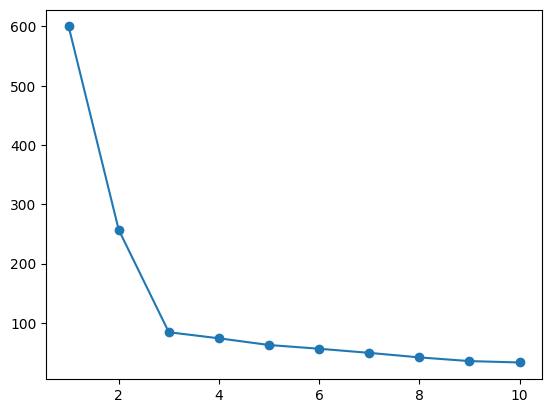

In [ ]:
plt.plot(K_range, inertia, marker='o')

In [ ]:
# so we will make 3 cluster points as the best point is k=3

In [ ]:
kmeans_final = KMeans(n_clusters=3 , random_state=42)

In [ ]:


cluster_labels = kmeans_final.fit_predict(X_scaled)

In [ ]:
cluster_labels

array([0, 2, 0, 1, 1, 1, 2, 0, 1, 1, 2, 2, 2, 0, 2, 1, 0, 0, 1, 2, 1, 0,
       2, 0, 1, 1, 0, 1, 2, 2, 1, 0, 0, 2, 2, 1, 2, 1, 0, 2, 1, 2, 0, 2,
       2, 1, 2, 1, 1, 2, 1, 2, 1, 1, 2, 0, 0, 1, 1, 0, 2, 2, 0, 1, 2, 1,
       0, 2, 0, 2, 1, 1, 1, 1, 2, 0, 2, 1, 0, 0, 1, 0, 2, 0, 0, 0, 2, 1,
       0, 0, 1, 2, 1, 0, 2, 2, 0, 2, 1, 0, 2, 1, 0, 2, 0, 0, 1, 0, 2, 2,
       0, 1, 0, 0, 1, 1, 0, 0, 2, 2, 2, 1, 2, 2, 2, 1, 2, 2, 2, 1, 1, 1,
       0, 1, 1, 2, 1, 0, 1, 1, 2, 0, 2, 0, 1, 1, 0, 1, 1, 2, 0, 1, 0, 2,
       1, 1, 2, 2, 0, 2, 0, 0, 2, 0, 1, 0, 0, 0, 0, 1, 2, 0, 1, 2, 2, 2,
       0, 2, 0, 0, 2, 1, 0, 0, 0, 0, 2, 1, 0, 1, 0, 0, 2, 2, 1, 0, 2, 1,
       0, 1, 2, 1, 0, 1, 2, 1, 0, 1, 0, 2, 0, 0, 1, 2, 2, 2, 2, 0, 1, 2,
       0, 2, 2, 2, 0, 1, 1, 0, 0, 1, 0, 2, 2, 0, 2, 1, 1, 1, 0, 0, 2, 1,
       1, 1, 1, 2, 1, 1, 0, 2, 2, 0, 2, 2, 1, 0, 2, 1, 0, 0, 1, 0, 1, 1,
       0, 1, 0, 2, 2, 2, 2, 0, 0, 0, 0, 0, 1, 1, 2, 0, 0, 2, 2, 2, 1, 2,
       1, 1, 2, 2, 1, 1, 1, 2, 0, 0, 1, 2, 0, 1], d

In [ ]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

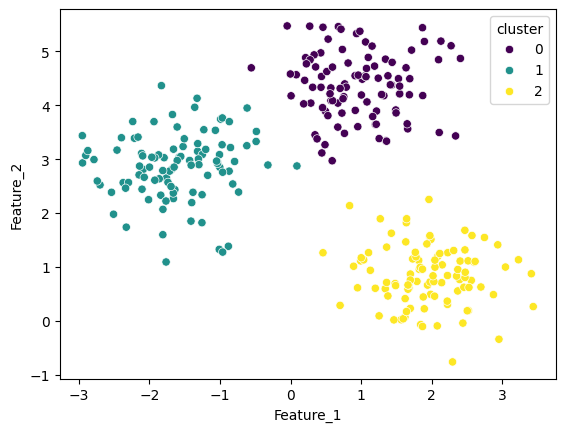

In [ ]:


sns.scatterplot(x=df['Feature_1'
],
                y=df['Feature_2'],
                hue=df['cluster'],
                palette='viridis')

# IMPLEMENTATION OF DB SCAN ALGORITHM

In [ ]:
from sklearn.datasets import make_moons
X, y_true = make_moons(n_samples=500, noise=0.05, random_state=42)

In [ ]:
from sklearn.cluster import KMeans, DBSCAN

In [ ]:

df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])

In [ ]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [ ]:


kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

In [ ]:

df['kmeans_cluster'] = kmeans_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

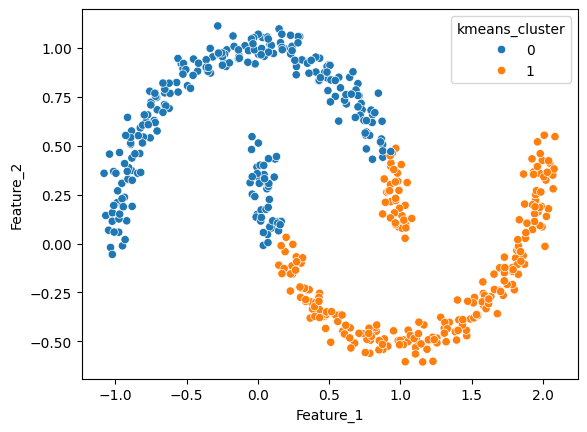

In [ ]:

sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['kmeans_cluster'], palette='tab10')



In [ ]:
# no we will apply db scan in the above to have separate cluster points

In [ ]:

dbscan = DBSCAN(eps=0.3, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

In [ ]:

df['dbscan_cluster'] = dbscan_labels


<Axes: xlabel='Feature_1', ylabel='Feature_2'>

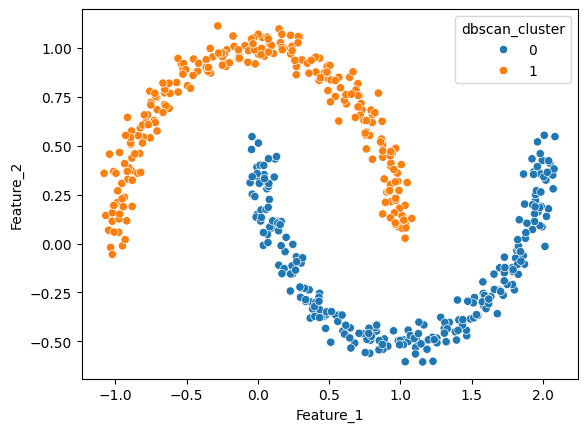

In [ ]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['dbscan_cluster'], palette='tab10')

